In [1]:
import pandas as pd

In [2]:
df = pd.read_pickle("../Data/random_pc_r_5_da_2_bal/all_preds_gramneg_capsid.pkl")
print(df.shape)
print(df.head())
print(df.dtypes)

(44804, 38)
                Vibrio_capsid  Pseudomonas_capsid  Salmonella_capsid  \
proteinID                                                              
AB002632_00003       0.892029            0.006306           0.009383   
AB002632_00005       0.884198            0.039370           0.016259   
AB002632_00006       0.960939            0.002251           0.005723   
AB002632_00007       0.887575            0.009491           0.011740   
AB008550_00005       0.003117            0.052489           0.009547   

                Microcystis_capsid  Escherichia_capsid  Ralstonia_capsid  \
proteinID                                                                  
AB002632_00003            0.081754            0.041862          0.003088   
AB002632_00005            0.015769            0.091740          0.374117   
AB002632_00006            0.007318            0.034375          0.000299   
AB002632_00007            0.021452            0.247610          0.040026   
AB008550_00005            0

In [3]:
# Look at the csvs
train = pd.read_csv("../Data/random_pc_r_5_da_2_bal/all_scores_trainset.csv")
print(train.shape)
print(train.head())
print(train.columns.tolist())

(2091, 6)
                Unnamed: 0  f1-score  precision    recall  accuracy  \
0      Campylobacter_lysin  0.318021   0.192582  0.912162  0.963479   
1  Campylobacter_endolysin  0.453488   0.327731  0.735849  0.978648   
2        Campylobacter_val  0.188312   0.105455  0.878788  0.940912   
3        Caulobacter_lysin  0.589831   0.428571  0.945652  0.992080   
4    Caulobacter_endolysin  0.782123   0.686275  0.909091  0.995474   

   bal_accuracy  
0      0.938062  
1      0.858728  
2      0.910094  
3      0.969007  
4      0.952672  
['Unnamed: 0', 'f1-score', 'precision', 'recall', 'accuracy', 'bal_accuracy']


In [4]:
meta = pd.read_csv("../Data/metadata.csv")  # adjust path
print(meta.shape)
print(meta.head(5).to_string())
print(meta.columns.tolist())

(1853074, 9)
        proteinID              pc accession      vc    host host_type                  phrogs_annotation                     phrogs_category  split
0  AB002632_00001  KP972568_00002  AB002632  VC_0_0  Vibrio  gram-neg   nicking at origin of replication  DNA, RNA and nucleotide metabolism      0
1  AB002632_00002  OP297622_00003  AB002632  VC_0_0  Vibrio  gram-neg  single strand DNA binding protein  DNA, RNA and nucleotide metabolism      0
2  AB002632_00003  KC357596_00003  AB002632  VC_0_0  Vibrio  gram-neg                 minor coat protein                  head and packaging      0
3  AB002632_00004  AB002632_00004  AB002632  VC_0_0  Vibrio  gram-neg                 minor head protein                  head and packaging      0
4  AB002632_00005  AB002632_00005  AB002632  VC_0_0  Vibrio  gram-neg                 major coat protein                  head and packaging      0
['proteinID', 'pc', 'accession', 'vc', 'host', 'host_type', 'phrogs_annotation', 'phrogs_category',

In [5]:
ht = pd.read_csv("../Data/host_type_all_preds.csv")
print(ht.shape)
print(ht.head(3).to_string())
print(ht.columns.tolist())

(1853074, 41)
        proteinID  host_type_lysin  host_type_endolysin  host_type_val  host_type_capsid  host_type_baseplate  host_type_tail_appendage  host_type_tail_sheath  host_type_portal  host_type_head-tail_joining  host_type_integration  host_type_nuclease  host_type_DNA_polymerase  host_type_terminase  host_type_annealing  host_type_helicase  host_type_primase  host_type_replication_initiation  host_type_transcriptional_regulator  host_type_transcriptional_activator  host_type_transcriptional_repressor  host_type_packaging_assembly  host_type_adsorption-related  host_type_cell_wall_depolymerase  host_type_RNA-associated  host_type_nucleotide_metabolism  host_type_ejection  host_type_phosphorylation  host_type_transferase  host_type_reductase  host_type_anti-restriction  host_type_sir2  host_type_toxin  host_type_super_infection  host_type_lysis  host_type_lysis_inhibitor  host_type_holin  host_type_spanin  host_type_tail  host_type_pvp  host_type_DNA-associated
0  AB002632_00001

# Gram Type Classification

We will apply both the conformal prediction envelope methods to the data to seperate gram negtaive host phages from gram positive host phages

Steps:
   1. Loading the protein level scoers (`host_type_all_preds.csv`) and metadata (`metadata.csv`)
   2. Joining on the `proteinID` to attach gram_type labels to each of the score rows
   3. Max pooling the protein scores to get one (40, ) score vector per phage
   4. Splitting into the defined train and test sets using the `split` column from `metadata.csv`
   5. Building one envelope per gram type using the training data
   6. Evaluating the results on the test phages - checking if the true gram type is in the prediction set
   7. Compare the reults from both the different methods (raidal vs strip)

**Decision rule**
   - `s1` inside the gram-neg envelope → phage is predicted to infect gram-negative hosts
   - `s1` inside the gram-pos envelope → phage is predicted to infect gram-positive hosts
   - Both → uncertain (prediction set size 2)
   - Neither → empty prediction set

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
import warnings
warnings.filterwarnings('ignore')

# random seed for reproducibility
np.random.seed(13)

### Loading the data
Loading the following two files:
   - `host_type_all_preds.csv`: conatins the protein-level scores for gram type prediction (40 function columns)
   - `metadata.csv`: contains protein-level metadata including `accession` (phage ID), `host_type` (gram-neg/gram-pos), and `split` (train=0 / test=1)

   
Both files have one row per protein and share the `proteinID` index.

In [2]:
SCORES_PATH   = "../Data/host_type_all_preds.csv"   # protein-level gram-type scores
METADATA_PATH = "../Data/metadata.csv"              # protein metadata with labels,

print("Loading scores...")
t0 = time.time()
scores_df = pd.read_csv(SCORES_PATH, index_col="proteinID")
print(f" scores shape : {scores_df.shape}  ({time.time()-t0:.1f}s)")
print("Loading metadata...")
t0 = time.time()
meta_df = pd.read_csv(METADATA_PATH, index_col="proteinID")    
print(f"metadata shape : {meta_df.shape}  ({time.time()-t0:.1f}s)")

# Keeping only the columns we need from metadata
meta_df = meta_df[["accession", "host_type", "split"]]

Loading scores...
 scores shape : (1853074, 40)  (2.7s)
Loading metadata...
metadata shape : (1853074, 8)  (2.6s)


### Joining the Scores and Metadata
Joining on `proteinID` so that we can attach the gram-type labels and phage accession to each score row (In order to get one combined DataFrame)

In [3]:
# Keeping only proteins that appear in both files,
combined = scores_df.join(meta_df, how="inner")    
print(f"Combined shape after joining: {combined.shape}")

# Identifying the 40 score columns (all columns starting with 'host_type_')
score_cols = [c for c in scores_df.columns if c.startswith("host_type_")]
print(f"Number of score (function) columns: {len(score_cols)}")

# Checking the gram-type label distribution
print("\nGram-type distribution (protein level):")
print(combined["host_type"].value_counts())

# Checking the train/test split distribution
print("\nSplit distribution (0=train, 1=test):")
print(combined["split"].value_counts())

Combined shape after joining: (1853074, 43)
Number of score (function) columns: 40

Gram-type distribution (protein level):
host_type
gram-neg    1151735
gram-pos     699623
unknown        1716
Name: count, dtype: int64

Split distribution (0=train, 1=test):
split
0    408069
4    387465
2    373117
3    371171
1    313252
Name: count, dtype: int64


### Max-Pooling Proteins → Phage-Level Scores
Each phage has many proteins. We aggregate from protein level to phage level using max pooling. So, for each phage and each function column, take the maximum we will take the maximum score across all its proteins.

This is because if any single protein strongly signals a gram-type association that is evidence for the whole phage

NaN remains NaN only if ALL proteins in a phage are NaN for that function (which means that no protein in that phage was annotated with that function).

In [4]:
print("Max-pooling proteins to phage level...")
t0 = time.time()

# Grouping by phage accession and taking the max across proteins
# skipna=True (default) means NaN is ignored unless ALL values are NaN

phage_scores = combined.groupby("accession")[score_cols].max()
print(f"  Phage-level scores shape: {phage_scores.shape}  ({time.time()-t0:.1f}s)")

# Attach phage-level labels: each phage has one gram type and one split value
# We use first() since all proteins of a phage share the same accession/host_type/split
phage_meta = combined.groupby("accession")[["host_type", "split"]].first()
phage_df   = phage_scores.join(phage_meta)    
print(f"  Phage-level DataFrame shape: {phage_df.shape}")
print(f"\nGram-type distribution (phage level):")
print(phage_df["host_type"].value_counts())
print(f"\nTrain/test split (phage level):")
print(phage_df["split"].value_counts())

Max-pooling proteins to phage level...
  Phage-level scores shape: (18474, 40)  (0.4s)
  Phage-level DataFrame shape: (18474, 42)

Gram-type distribution (phage level):
host_type
gram-neg    10735
gram-pos     7708
unknown        31
Name: count, dtype: int64

Train/test split (phage level):
split
0    4433
2    3646
4    3634
3    3588
1    3173
Name: count, dtype: int64


### Preparing Train / Test Sets

Using the `split` column

For each gram type, we will extract the training phages that infect that gram type these are the calibration infectors used to build the envelope.

NaN handling: columns where a phage has no score (all proteins were NaN for that function) remain NaN. We drop all-NaN columns and fill remaining NaNs with 0 only for the envelope input (since an absent function = no signal = 0).

In [5]:
# Separating train and test at phage level
train_df = phage_df[phage_df["split"] != 0]
test_df  = phage_df[phage_df["split"] == 0]

print(f"Train phages: {len(train_df)}  |  Test phages: {len(test_df)}")

# Dropping columns that are entirely NaN across ALL phages (unusable functions)
valid_cols = [c for c in score_cols if phage_df[c].notna().any()]
print(f"Score columns after dropping all-NaN: {len(valid_cols)} / {len(score_cols)}")

def get_score_matrix(df, gram_type):
    """
    Returns a (N, K) numpy array of max-pooled scores for phages
    whose host_type matches gram_type.
    NaN values are filled with 0 (absent function = no evidence).
    """
    subset = df[df["host_type"] == gram_type][valid_cols]
    return subset.fillna(0).values, subset.index.tolist()

# Training calibration sets (one per gram type)
train_gramneg, train_gramneg_ids = get_score_matrix(train_df, "gram-neg")
train_grampos, train_grampos_ids = get_score_matrix(train_df, "gram-pos")

print(f"\nTraining infectors:")
print(f"  gram-neg: {train_gramneg.shape}")
print(f"  gram-pos: {train_grampos.shape}")

# Full test score matrix (all gram types)
test_scores_all = test_df[valid_cols].fillna(0).values
test_labels     = test_df["host_type"].values
test_ids        = test_df.index.tolist()

K = len(valid_cols)

Train phages: 14041  |  Test phages: 4433
Score columns after dropping all-NaN: 40 / 40

Training infectors:
  gram-neg: (7924, 40)
  gram-pos: (6097, 40)


###  Envelope Methods

Using the two methods developed

In [6]:
def split_data(scores, split_ratio=0.5):
    """Randomly splits scores into S1 (shape discovery) and S2 (size scaling)."""
    n   = len(scores)
    idx = np.random.permutation(n)
    cut = int(n * split_ratio)
    return scores[idx[:cut]], scores[idx[cut:]]

#### Radial Method

In [7]:
def sample_positive_sphere(M, K):
    V     = np.abs(np.random.randn(M, K))
    norms = np.linalg.norm(V, axis=1, keepdims=True)
    return V / (norms + 1e-12)

def radial_shape_discovery(S1, alpha, M, delta_deg=15):
    K    = S1.shape[1]
    U    = sample_positive_sphere(M, K)
    mags = np.linalg.norm(S1, axis=1)
    dirs = S1 / (mags[:, None] + 1e-12)
    cos_thresh = np.cos(np.radians(delta_deg))
    q_tilde    = np.zeros(M)

    for m in range(M):
        sims = dirs @ U[m]
        mask = sims >= cos_thresh
        if mask.sum() < 5:
            q_tilde[m] = np.quantile(mags, 1 - alpha)
        else:
            q_tilde[m] = np.quantile(mags[mask], 1 - alpha)
    return U, q_tilde

def radial_size_scaling(S2, U, q_tilde, alpha):
    boundary     = U * q_tilde[:, None]
    ratios       = S2[:, None, :] / (boundary[None, :, :] + 1e-12)
    t_per_sector = ratios.max(axis=2)
    tau_scores   = t_per_sector.min(axis=1)
    n2    = len(tau_scores)
    idx   = int(np.ceil((n2 + 1) * (1 - alpha))) - 1
    t_hat = np.sort(tau_scores)[np.clip(idx, 0, n2 - 1)]
    return t_hat

def radial_is_in_region(scores, envelope):
    U, q_tilde, t_hat = envelope["U"], envelope["q_tilde"], envelope["t_hat"]
    q_final  = q_tilde * t_hat
    boundary = U * q_final[:, None]
    inside   = np.any(
        np.all(scores[:, None, :] <= boundary[None, :, :], axis=2), axis=1
    )
    return inside

def radial_build_envelope(infection_scores, alpha, M=200, delta_deg=15):
    S1, S2     = split_data(infection_scores)
    U, q_tilde = radial_shape_discovery(S1, alpha, M, delta_deg)
    t_hat      = radial_size_scaling(S2, U, q_tilde, alpha)
    return {"U": U, "q_tilde": q_tilde, "t_hat": t_hat, "method": "radial"}

#### Strips Method

In [8]:
def strip_shape_discovery(S1, alpha, M):
    N1, K = S1.shape
    bin_edges = np.zeros((K, M + 1))
    for j in range(K):
        bin_edges[j] = np.linspace(S1[:, j].min(), S1[:, j].max(), M + 1)

    limits = np.zeros((K, K, M))
    for j in range(K):
        for m in range(M):
            lo, hi   = bin_edges[j, m], bin_edges[j, m + 1]
            in_strip = (S1[:, j] >= lo) & (S1[:, j] < hi)
            for i in range(K):
                if i == j: continue
                if in_strip.sum() < 3:
                    limits[j, i, m] = np.quantile(S1[:, i], 1 - alpha)
                else:
                    limits[j, i, m] = np.quantile(S1[in_strip, i], 1 - alpha)

    for j in range(K):
        for i in range(K):
            if i == j: continue
            for m in range(M - 2, -1, -1):
                limits[j, i, m] = max(limits[j, i, m], limits[j, i, m + 1])
    return bin_edges, limits

def get_bin_indices(scores, bin_edges):
    N, K = scores.shape
    M    = bin_edges.shape[1] - 1
    indices = np.zeros((N, K), dtype=int)
    for j in range(K):
        raw = np.digitize(scores[:, j], bin_edges[j]) - 1
        indices[:, j] = np.clip(raw, 0, M - 1)
    return indices

def strip_size_scaling(S2, bin_edges, limits, alpha):
    N2, K   = S2.shape
    bin_idx = get_bin_indices(S2, bin_edges)
    ratios = np.zeros((N2, K, K))
    for j in range(K):
        for i in range(K):
            if i == j: continue
            lims = limits[j, i, bin_idx[:, j]]
            ratios[:, j, i] = S2[:, i] / (lims + 1e-12)
    tau_scores = ratios.max(axis=(1, 2))
    n2    = N2
    idx   = int(np.ceil((n2 + 1) * (1 - alpha))) - 1
    t_hat = np.sort(tau_scores)[np.clip(idx, 0, n2 - 1)]
    return t_hat

def strip_is_in_region(scores, envelope):
    bin_edges, limits, t_hat = envelope["bin_edges"], envelope["limits"], envelope["t_hat"]
    N, K          = scores.shape
    bin_idx       = get_bin_indices(scores, bin_edges)
    scaled_limits = limits * t_hat
    inside = np.ones(N, dtype=bool)
    for j in range(K):
        for i in range(K):
            if i == j: continue
            lims    = scaled_limits[j, i, bin_idx[:, j]]
            inside &= (scores[:, i] <= lims)
    return inside

def strip_build_envelope(infection_scores, alpha, M=20):
    S1, S2            = split_data(infection_scores)
    bin_edges, limits = strip_shape_discovery(S1, alpha, M)
    t_hat             = strip_size_scaling(S2, bin_edges, limits, alpha)
    return {"bin_edges": bin_edges, "limits": limits, "t_hat": t_hat, "method": "strip"}

#### Functions that work on both methods

In [9]:
def is_in_region(scores, envelope):
    if envelope["method"] == "radial":
        return radial_is_in_region(scores, envelope)
    else:
        return strip_is_in_region(scores, envelope)

def predict_gram_type(test_scores, envelopes):
    in_gramneg = is_in_region(test_scores, envelopes["gram-neg"])
    in_grampos = is_in_region(test_scores, envelopes["gram-pos"])
    results = []
    for i in range(len(test_scores)):
        pred_set = []
        if in_gramneg[i]: pred_set.append("gram-neg")
        if in_grampos[i]: pred_set.append("gram-pos")
        results.append({
            "in_gramneg"      : bool(in_gramneg[i]),
            "in_grampos"      : bool(in_grampos[i]),
            "prediction_set"  : pred_set,
        })
    return results

### Building Envelopes on the Training Data

Building one envelope per gram type per method using the training infectors

In [10]:
alpha = 0.1 

print("Building radial envelopes...")
t0 = time.time()
radial_envelopes = {
    "gram-neg": radial_build_envelope(train_gramneg, alpha, M=200, delta_deg=15),
    "gram-pos": radial_build_envelope(train_grampos, alpha, M=200, delta_deg=15),
}
print(f"  Done in {time.time()-t0:.1f}s")

print("\nBuilding strip envelopes...")
t0 = time.time()
strip_envelopes = {
    "gram-neg": strip_build_envelope(train_gramneg, alpha, M=20),
    "gram-pos": strip_build_envelope(train_grampos, alpha, M=20),
}
print(f"  Done in {time.time()-t0:.1f}s")

Building radial envelopes...
  Done in 0.3s

Building strip envelopes...
  Done in 5.1s


#### Evaluating on the Test Set

For each test phage we check:
- **Coverage**: is the true gram type in the prediction set? (should be >= 1-alpha)
- **Efficiency**: how large is the prediction set on average? (smaller is better)
- **Accuracy**: when the prediction set has size 1, is it the correct gram type?

In [11]:
def evaluate(results, true_labels, method_name):
    n          = len(results)
    covered    = sum(r["prediction_set"].count(true_labels[i]) > 0
                     for i, r in enumerate(results))
    set_sizes  = [len(r["prediction_set"]) for r in results]
    empty      = sum(s == 0 for s in set_sizes)
    singletons = [(r, true_labels[i]) for i, r in enumerate(results)
                  if len(r["prediction_set"]) == 1]
    correct_singletons = sum(r["prediction_set"][0] == lbl for r, lbl in singletons)

    print(f"\n{'='*55}\n {method_name.upper()} METHOD — Results on {n} test phages\n{'='*55}")
    print(f" Coverage (true gram type in set) : {covered/n:.3f}  (target >= {1-alpha:.2f})")
    print(f" Average prediction set size      : {np.mean(set_sizes):.3f}")
    print(f" Empty prediction sets            : {empty} ({empty/n*100:.1f}%)")
    print(f" Singleton accuracy               : {correct_singletons/len(singletons):.3f}" if singletons else "N/A")

    return {
        "coverage": covered / n,
        "avg_set_size": np.mean(set_sizes),
        "empty_rate": empty / n,
        "singleton_rate": len(singletons) / n,
        "singleton_accuracy": correct_singletons / len(singletons) if singletons else None,
        "set_sizes": set_sizes,
    }

radial_results = predict_gram_type(test_scores_all, radial_envelopes)
strip_results  = predict_gram_type(test_scores_all, strip_envelopes)

radial_metrics = evaluate(radial_results, test_labels, "Radial")
strip_metrics  = evaluate(strip_results,  test_labels, "Strip")


 RADIAL METHOD — Results on 4433 test phages
 Coverage (true gram type in set) : 0.886  (target >= 0.90)
 Average prediction set size      : 1.526
 Empty prediction sets            : 269 (6.1%)
 Singleton accuracy               : 0.856

 STRIP METHOD — Results on 4433 test phages
 Coverage (true gram type in set) : 0.885  (target >= 0.90)
 Average prediction set size      : 1.138
 Empty prediction sets            : 492 (11.1%)
 Singleton accuracy               : 0.996


### Comparision of both methods.

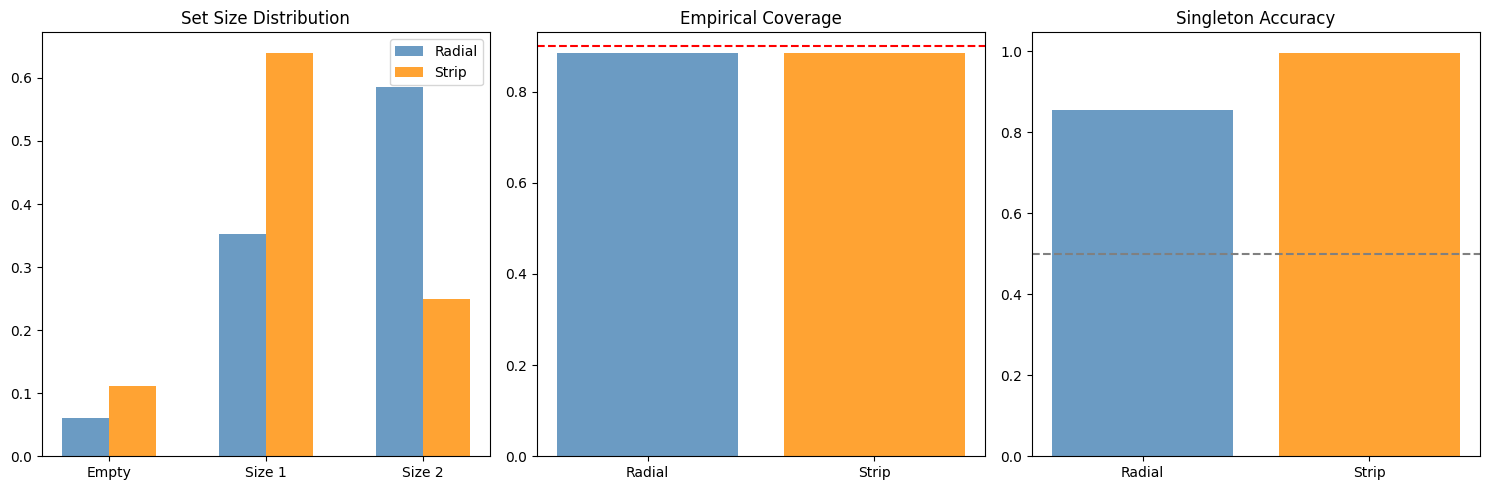

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
methods   = ["Radial", "Strip"]
metrics   = [radial_metrics, strip_metrics]
colors    = ["steelblue", "darkorange"]

# Plot 1: Sizes
ax = axes[0]
for name, m, c in zip(methods, metrics, colors):
    sizes = m["set_sizes"]
    counts = [sizes.count(s) / len(sizes) for s in [0, 1, 2]]
    x = np.array([0, 1, 2])
    offset = -0.15 if name == "Radial" else 0.15
    ax.bar(x + offset, counts, width=0.3, label=name, color=c, alpha=0.8)
ax.set_xticks([0, 1, 2])
ax.set_xticklabels(["Empty", "Size 1", "Size 2"])
ax.set_title("Set Size Distribution")
ax.legend()

# Plot 2: Coverage
ax = axes[1]
covs = [radial_metrics["coverage"], strip_metrics["coverage"]]
ax.bar(methods, covs, color=colors, alpha=0.8)
ax.axhline(1 - alpha, color="red", linestyle="--", label="Target")
ax.set_title("Empirical Coverage")

# Plot 3: Accuracy
ax = axes[2]
accs = [radial_metrics["singleton_accuracy"] or 0, strip_metrics["singleton_accuracy"] or 0]
ax.bar(methods, accs, color=colors, alpha=0.8)
ax.axhline(0.5, color="gray", linestyle="--", label="Random")
ax.set_title("Singleton Accuracy")

plt.tight_layout()
plt.show()

#### Summary Table

In [13]:
summary = pd.DataFrame({
    "Method": ["Radial", "Strip"],
    "Coverage": [radial_metrics["coverage"], strip_metrics["coverage"]],
    "Avg set size": [radial_metrics["avg_set_size"], strip_metrics["avg_set_size"]],
    "Singleton accuracy": [radial_metrics["singleton_accuracy"], strip_metrics["singleton_accuracy"]],
})
print("\n", summary.to_string(index=False))


 Method  Coverage  Avg set size  Singleton accuracy
Radial  0.885856      1.525603            0.855591
 Strip  0.884728      1.137830            0.996476
